In [1]:
from pathlib import Path
import json
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.datasets import CIFAR100, OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Директории
if Path.cwd().name == "HW10-11":
    ROOT = Path.cwd()
else:
    ROOT = Path("homeworks") / "HW10-11"

ARTIFACTS = ROOT / "artifacts"
FIGURES = ARTIFACTS / "figures"
DATA_DIR = ROOT / "data"

ARTIFACTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

FAST_MODE = True
print("FAST_MODE =", FAST_MODE)

Device: cpu
FAST_MODE = True


In [3]:
# 2. Подготовка данных для классификации (часть A)
# 2.1. Трансформации
base_transform = transforms.Compose([transforms.ToTensor()])
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])

try:
    resnet_weights = ResNet18_Weights.IMAGENET1K_V1
    # Проверка доступности весов (необязательно, но улучшает отладку)
    _ = resnet_weights.transforms()
except Exception as e:
    print(f"Не удалось загрузить предобученные веса для ResNet18: {e}. Будет использована модель без предобучения.")
    resnet_weights = None
if resnet_weights is not None:
    resnet_transform = resnet_weights.transforms()
else:
    resnet_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

# 2.2. Загрузка и разделение CIFAR100
trainval_full = CIFAR100(root=DATA_DIR, train=True, download=True, transform=base_transform)
test_raw = CIFAR100(root=DATA_DIR, train=False, download=True, transform=base_transform)

val_size = int(0.2 * len(trainval_full))
train_size = len(trainval_full) - val_size
split_gen = torch.Generator().manual_seed(SEED)
train_raw, val_raw = random_split(trainval_full, [train_size, val_size], generator=split_gen)

if FAST_MODE:
    train_raw = Subset(train_raw, range(min(8000, len(train_raw))))
    val_raw = Subset(val_raw, range(min(2000, len(val_raw))))
    test_raw = Subset(test_raw, range(min(2000, len(test_raw))))

batch_size = 128 if device.type == "cuda" else 64

# 2.3. DataLoader для базовой CNN
train_loader_base = DataLoader(train_raw, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_base = DataLoader(val_raw, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader_base = DataLoader(test_raw, batch_size=batch_size, shuffle=False, num_workers=0)

# 2.4. DataLoader для аугментированной CNN
trainval_aug = CIFAR100(root=DATA_DIR, train=True, download=False, transform=aug_transform)
train_aug, val_aug = random_split(trainval_aug, [train_size, val_size], generator=split_gen)
if FAST_MODE:
    train_aug = Subset(train_aug, range(min(8000, len(train_aug))))
    val_aug = Subset(val_aug, range(min(2000, len(val_aug))))
train_loader_aug = DataLoader(train_aug, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_aug = DataLoader(val_aug, batch_size=batch_size, shuffle=False, num_workers=0)

# 2.5. DataLoader для ResNet
trainval_resnet = CIFAR100(root=DATA_DIR, train=True, download=False, transform=resnet_transform)
test_resnet = CIFAR100(root=DATA_DIR, train=False, download=False, transform=resnet_transform)
train_resnet, val_resnet = random_split(trainval_resnet, [train_size, val_size], generator=split_gen)
if FAST_MODE:
    train_resnet = Subset(train_resnet, range(min(8000, len(train_resnet))))
    val_resnet = Subset(val_resnet, range(min(2000, len(val_resnet))))
    test_resnet = Subset(test_resnet, range(min(2000, len(test_resnet))))
train_loader_resnet = DataLoader(train_resnet, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_resnet = DataLoader(val_resnet, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader_resnet = DataLoader(test_resnet, batch_size=batch_size, shuffle=False, num_workers=0)

# 2.6. Проверка batch
x_batch, y_batch = next(iter(train_loader_base))
print("Часть A: x.shape =", tuple(x_batch.shape), "y.shape =", tuple(y_batch.shape))

d:\DPO_MIREA\aie_goldobin_rsbo-01-24\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Часть A: x.shape = (64, 3, 32, 32) y.shape = (64,)


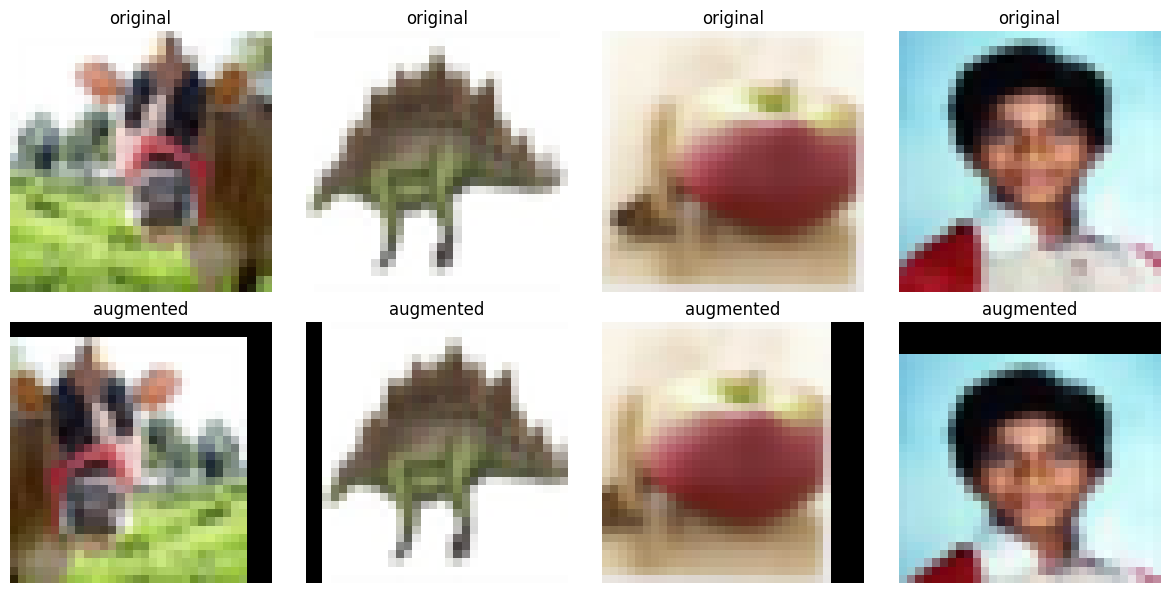

In [4]:
# 3. Визуализация аугментаций
raw_ds = CIFAR100(root=DATA_DIR, train=True, download=False, transform=None)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    img, _ = raw_ds[i]
    axes[0, i].imshow(img)
    axes[0, i].set_title("original")
    axes[0, i].axis("off")
    aug_img = aug_transform(img).permute(1, 2, 0).numpy()
    axes[1, i].imshow(np.clip(aug_img, 0, 1))
    axes[1, i].set_title("augmented")
    axes[1, i].axis("off")
plt.tight_layout()
plt.savefig(FIGURES / "augmentations_preview.png", dpi=140)
plt.show()

In [5]:
# 4. Определение моделей и вспомогательных функций для классификации
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

def build_resnet(mode, num_classes=100):
    if resnet_weights is not None:
        model = resnet18(weights=resnet_weights)
    else:
        model = resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    if mode == "head-only":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
    elif mode == "finetune-layer4-fc":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        raise ValueError("Неизвестный режим")
    return model

def run_exp(exp_id, model, train_loader, val_loader, epochs, lr):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
        print(f"{exp_id} | epoch {epoch}/{epochs} | tr_acc={tr_acc:.4f} | va_acc={va_acc:.4f}")
    return {
        "exp_id": exp_id,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_state": best_state,
        "epochs_trained": epochs,
        "lr": lr,
    }

In [6]:
# 5. Запуск экспериментов C1-C4
epochs_cnn = 2 if FAST_MODE else 8
epochs_resnet = 2 if FAST_MODE else 6
lr_cnn = 1e-3
lr_resnet = 3e-4

results = {}
results["C1"] = run_exp("C1", SimpleCNN(100), train_loader_base, val_loader_base,
                        epochs_cnn, lr_cnn)
results["C2"] = run_exp("C2", SimpleCNN(100), train_loader_aug, val_loader_aug,
                        epochs_cnn, lr_cnn)
results["C3"] = run_exp("C3", build_resnet("head-only", 100), train_loader_resnet,
                        val_loader_resnet, epochs_resnet, lr_resnet)
results["C4"] = run_exp("C4", build_resnet("finetune-layer4-fc", 100), train_loader_resnet,
                        val_loader_resnet, epochs_resnet, lr_resnet)

best_id = max(["C1", "C2", "C3", "C4"], key=lambda k: results[k]["best_val_acc"])
print("Лучший эксперимент классификации:", best_id, "val_acc =", results[best_id]["best_val_acc"])

C1 | epoch 1/2 | tr_acc=0.0194 | va_acc=0.0315
C1 | epoch 2/2 | tr_acc=0.0398 | va_acc=0.0515
C2 | epoch 1/2 | tr_acc=0.0179 | va_acc=0.0210
C2 | epoch 2/2 | tr_acc=0.0370 | va_acc=0.0450
C3 | epoch 1/2 | tr_acc=0.0673 | va_acc=0.1470
C3 | epoch 2/2 | tr_acc=0.2370 | va_acc=0.2800
C4 | epoch 1/2 | tr_acc=0.3530 | va_acc=0.4965
C4 | epoch 2/2 | tr_acc=0.7361 | va_acc=0.5625
Лучший эксперимент классификации: C4 val_acc = 0.5625


Точность лучшей модели на тесте: 0.5475


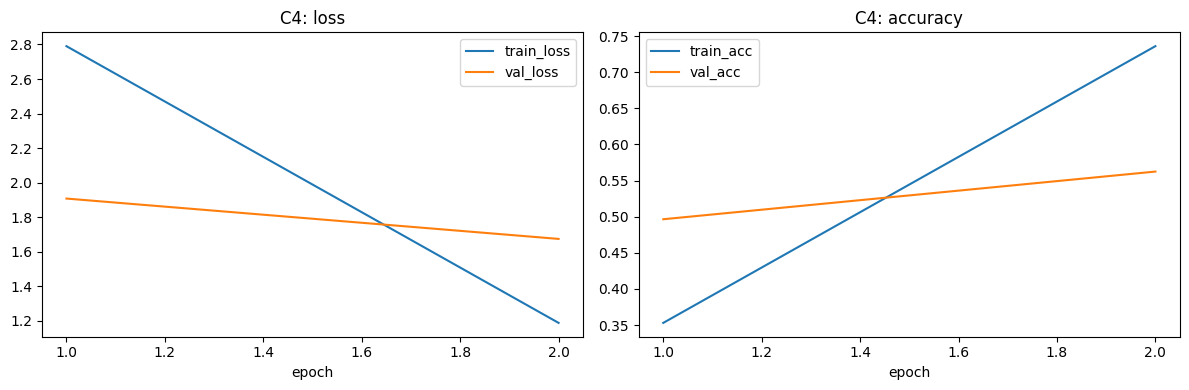

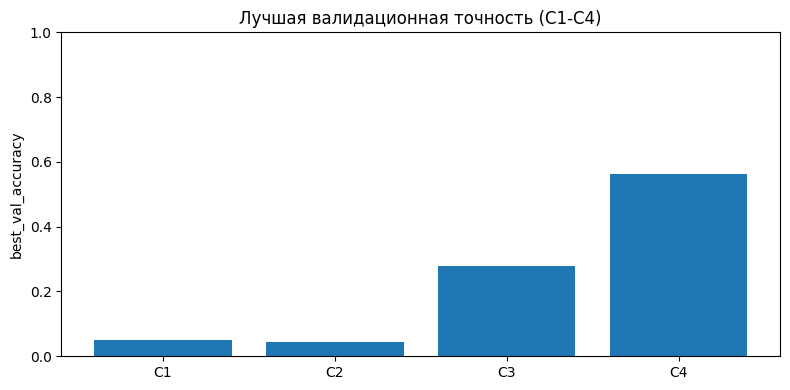

In [7]:
# 6. Сохранение лучшего классификатора и графики
if best_id in ("C1", "C2"):
    best_model = SimpleCNN(100)
    best_test_loader = test_loader_base
    model_desc = "SimpleCNN"
    train_transform_name = "base" if best_id == "C1" else "augmented"
else:
    mode = "head-only" if best_id == "C3" else "finetune-layer4-fc"
    best_model = build_resnet(mode, 100)
    best_test_loader = test_loader_resnet
    model_desc = f"ResNet18-{mode}"
    train_transform_name = "resnet_preprocess"

best_model.load_state_dict(results[best_id]["best_state"])
best_model = best_model.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, best_test_loader, criterion, device)
print("Точность лучшей модели на тесте:", round(test_acc, 4))

torch.save(best_model.state_dict(), ARTIFACTS / "best_classifier.pt")
config = {
    "dataset": "CIFAR100",
    "seed": SEED,
    "best_experiment_id": best_id,
    "model_summary": model_desc,
    "train_transform": train_transform_name,
    "optimizer": "Adam",
    "lr": float(results[best_id]["lr"]),
    "epochs_trained": int(results[best_id]["epochs_trained"]),
    "best_val_accuracy": float(results[best_id]["best_val_acc"]),
    "test_accuracy": float(test_acc),
    "fast_mode": FAST_MODE,
}
with open(ARTIFACTS / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

# Кривые лучшего эксперимента
hist = results[best_id]["history"]
epochs_axis = np.arange(1, len(hist["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs_axis, hist["train_loss"], label="train_loss")
ax[0].plot(epochs_axis, hist["val_loss"], label="val_loss")
ax[0].set_title(f"{best_id}: loss")
ax[0].set_xlabel("epoch")
ax[0].legend()
ax[1].plot(epochs_axis, hist["train_acc"], label="train_acc")
ax[1].plot(epochs_axis, hist["val_acc"], label="val_acc")
ax[1].set_title(f"{best_id}: accuracy")
ax[1].set_xlabel("epoch")
ax[1].legend()
plt.tight_layout()
plt.savefig(FIGURES / "classification_curves_best.png", dpi=140)
plt.show()

# Сравнение C1-C4
ids = ["C1", "C2", "C3", "C4"]
vals = [results[i]["best_val_acc"] for i in ids]
plt.figure(figsize=(8, 4))
plt.bar(ids, vals)
plt.ylim(0, 1)
plt.title("Лучшая валидационная точность (C1-C4)")
plt.ylabel("best_val_accuracy")
plt.tight_layout()
plt.savefig(FIGURES / "classification_compare.png", dpi=140)
plt.show()

In [8]:
# 7. Подготовка данных для сегментации (часть B)
class PetSegDataset(torch.utils.data.Dataset):
    def __init__(self, split="trainval", image_size=256):
        self.ds = OxfordIIITPet(
            root=DATA_DIR,
            split=split,
            target_types="segmentation",
            download=True,
        )
        self.img_size = image_size
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, mask = self.ds[idx]
        img = self.img_transform(img)
        mask = transforms.functional.resize(
            mask, (self.img_size, self.img_size),
            interpolation=transforms.InterpolationMode.NEAREST
        )
        mask = torch.as_tensor(np.array(mask), dtype=torch.int64)
        # в trimap: 1 = животное, 2 = фон, 3 = граница
        fg = (mask == 1).to(torch.int64)
        return img, fg

seg_trainval = PetSegDataset(split="trainval", image_size=256)
seg_test = PetSegDataset(split="test", image_size=256)

if FAST_MODE:
    seg_test = Subset(seg_test, range(min(60, len(seg_test))))

seg_loader = DataLoader(seg_test, batch_size=4, shuffle=False, num_workers=0)
xb, yb = next(iter(seg_loader))
print("Часть B: x.shape =", tuple(xb.shape), "y.shape =", tuple(yb.shape))

seg_weights = FCN_ResNet50_Weights.DEFAULT if FCN_ResNet50_Weights else None
seg_model = fcn_resnet50(weights=seg_weights).to(device).eval() if seg_weights else fcn_resnet50(weights=None).to(device).eval()

Часть B: x.shape = (4, 3, 256, 256) y.shape = (4, 256, 256)


In [9]:
# Постобработка для сегментации
# V1: бинаризация по порогу 0.5
def postprocess_v1(logits):
    probs = torch.softmax(logits, dim=1)
    fg_prob = 1.0 - probs[:, 0]
    return (fg_prob >= 0.5).to(torch.int64)

# V2: порог 0.7 + сглаживание средним фильтром
def postprocess_v2(logits):
    probs = torch.softmax(logits, dim=1)
    fg_prob = 1.0 - probs[:, 0]
    raw_mask = (fg_prob >= 0.7).float().unsqueeze(1)
    smoothed = F.avg_pool2d(raw_mask, kernel_size=5, stride=1, padding=2).squeeze(1)
    return (smoothed >= 0.5).to(torch.int64)

In [10]:
# 8. Функции для сегментации: постобработка и метрики

def iou_binary(pred, target, eps=1e-8):
    inter = ((pred == 1) & (target == 1)).sum().item()
    union = ((pred == 1) | (target == 1)).sum().item()
    return inter / (union + eps) if union != 0 else 1.0

def precision_recall_binary(pred, target, eps=1e-8):
    tp = ((pred == 1) & (target == 1)).sum().item()
    fp = ((pred == 1) & (target == 0)).sum().item()
    fn = ((pred == 0) & (target == 1)).sum().item()
    prec = tp / (tp + fp + eps)
    rec = tp / (tp + fn + eps)
    return prec, rec

@torch.no_grad()
def eval_segmentation(model, loader, postproc_fn):
    ious, precs, recs = [], [], []
    examples = []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)["out"]
        pred = postproc_fn(logits).cpu()
        for i in range(pred.shape[0]):
            p = pred[i]
            t = y[i]
            ious.append(iou_binary(p, t))
            pr, rc = precision_recall_binary(p, t)
            precs.append(pr)
            recs.append(rc)
            if len(examples) < 4:
                examples.append((x[i].cpu(), t, p))
    return {
        "mean_iou": float(np.mean(ious)),
        "pixel_precision": float(np.mean(precs)),
        "pixel_recall": float(np.mean(recs)),
        "examples": examples,
    }

metrics_v1 = eval_segmentation(seg_model, seg_loader, postprocess_v1)
metrics_v2 = eval_segmentation(seg_model, seg_loader, postprocess_v2)

print("V1: mean_iou =", metrics_v1["mean_iou"],
      "precision =", metrics_v1["pixel_precision"],
      "recall =", metrics_v1["pixel_recall"])
print("V2: mean_iou =", metrics_v2["mean_iou"],
      "precision =", metrics_v2["pixel_precision"],
      "recall =", metrics_v2["pixel_recall"])

V1: mean_iou = 0.6995913065709684 precision = 0.7588322068832783 recall = 0.882998155205287
V2: mean_iou = 0.7068954641165573 precision = 0.8295283787871425 recall = 0.8238875501093488


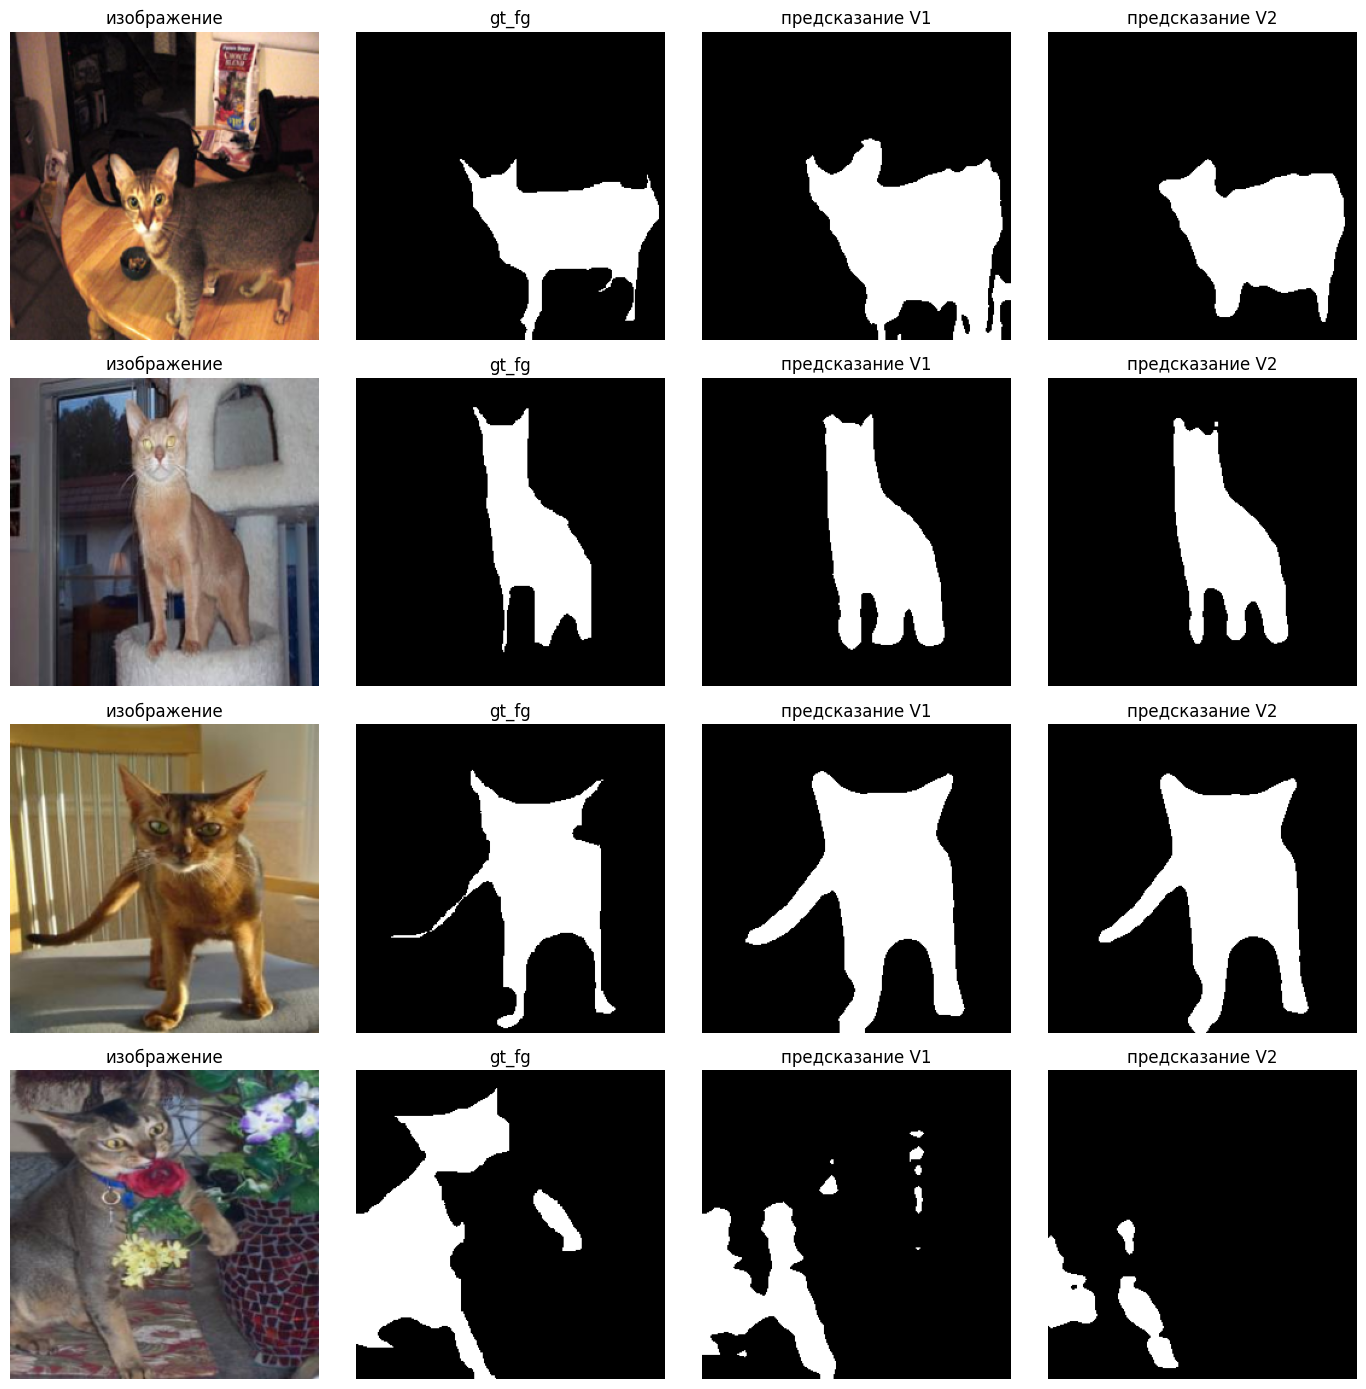

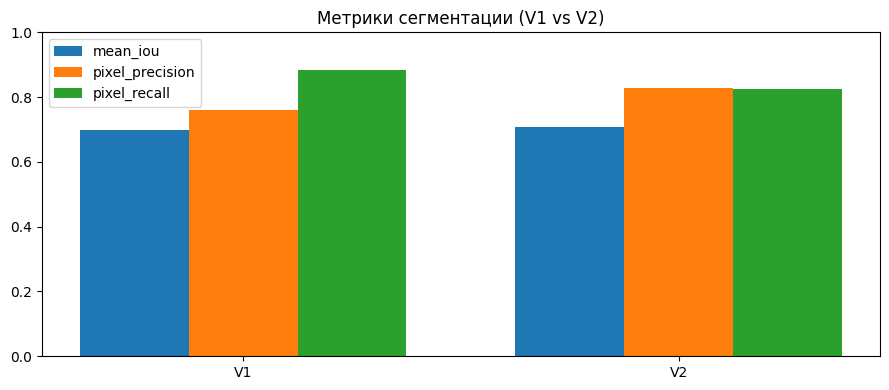

In [11]:
# 9. Визуализация сегментации
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for row in range(4):
    img, gt, pred_v1 = metrics_v1["examples"][row]
    _, _, pred_v2 = metrics_v2["examples"][row]
    img_np = np.transpose(img.numpy(), (1, 2, 0))
    axes[row, 0].imshow(np.clip(img_np, 0, 1))
    axes[row, 0].set_title("изображение")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(gt.numpy(), cmap="gray")
    axes[row, 1].set_title("gt_fg")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(pred_v1.numpy(), cmap="gray")
    axes[row, 2].set_title("предсказание V1")
    axes[row, 2].axis("off")
    axes[row, 3].imshow(pred_v2.numpy(), cmap="gray")
    axes[row, 3].set_title("предсказание V2")
    axes[row, 3].axis("off")
plt.tight_layout()
plt.savefig(FIGURES / "segmentation_examples.png", dpi=140)
plt.show()

# Сравнение метрик
labels = ["V1", "V2"]
miou = [metrics_v1["mean_iou"], metrics_v2["mean_iou"]]
prec = [metrics_v1["pixel_precision"], metrics_v2["pixel_precision"]]
rec = [metrics_v1["pixel_recall"], metrics_v2["pixel_recall"]]
x = np.arange(len(labels))
w = 0.25
plt.figure(figsize=(9, 4))
plt.bar(x - w, miou, width=w, label="mean_iou")
plt.bar(x, prec, width=w, label="pixel_precision")
plt.bar(x + w, rec, width=w, label="pixel_recall")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Метрики сегментации (V1 vs V2)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "segmentation_metrics.png", dpi=140)
plt.show()

In [12]:
# 10. Сохранение runs.csv
columns = [
    "experiment_id", "task", "dataset", "seed", "model_summary",
    "optimizer", "lr", "epochs_trained", "best_val_accuracy",
    "test_accuracy", "precision", "recall", "mean_iou", "notes"
]
rows = []
for exp_id in ["C1", "C2", "C3", "C4"]:
    row = {
        "experiment_id": exp_id,
        "task": "classification",
        "dataset": "CIFAR100",
        "seed": SEED,
        "model_summary": ("SimpleCNN" if exp_id in ("C1", "C2")
                          else ("ResNet18-head-only" if exp_id == "C3"
                                else "ResNet18-finetune-layer4-fc")),
        "optimizer": "Adam",
        "lr": results[exp_id]["lr"],
        "epochs_trained": results[exp_id]["epochs_trained"],
        "best_val_accuracy": results[exp_id]["best_val_acc"],
        "test_accuracy": test_acc if exp_id == best_id else np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": "C2 uses augmentation" if exp_id == "C2" else "",
    }
    rows.append(row)

rows.append({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "FCN_ResNet50(pretrained)",
    "optimizer": "",
    "lr": np.nan,
    "epochs_trained": 0,
    "best_val_accuracy": np.nan,
    "test_accuracy": np.nan,
    "precision": metrics_v1["pixel_precision"],
    "recall": metrics_v1["pixel_recall"],
    "mean_iou": metrics_v1["mean_iou"],
    "notes": "foreground = (class != background), thr=0.5",
})
rows.append({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "FCN_ResNet50(pretrained)",
    "optimizer": "",
    "lr": np.nan,
    "epochs_trained": 0,
    "best_val_accuracy": np.nan,
    "test_accuracy": np.nan,
    "precision": metrics_v2["pixel_precision"],
    "recall": metrics_v2["pixel_recall"],
    "mean_iou": metrics_v2["mean_iou"],
    "notes": "foreground = (class != background), thr=0.7 + smoothing",
})

df = pd.DataFrame(rows, columns=columns)
df.to_csv(ARTIFACTS / "runs.csv", index=False)
df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,2,0.0515,NaN,NaN,NaN,NaN,
1,C2,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,2,0.0450,NaN,NaN,NaN,NaN,C2 uses augmentation
2,C3,classification,CIFAR100,42,ResNet18-head-only,Adam,0.0003,2,0.2800,NaN,NaN,NaN,NaN,
3,C4,classification,CIFAR100,42,ResNet18-finetune-layer4-fc,Adam,0.0003,2,0.5625,0.5475,NaN,NaN,NaN,
4,V1,segmentation,OxfordIIITPet,42,FCN_ResNet50(pretrained),,NaN,0,NaN,NaN,0.758832,0.882998,0.699591,"foreground = (class != background), thr=0.5"
5,V2,segmentation,OxfordIIITPet,42,FCN_ResNet50(pretrained),,NaN,0,NaN,NaN,0.829528,0.823888,0.706895,"foreground = (class != background), thr=0.7 + ..."
